In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder



In [ ]:
!gdown 1zdPo7v3J4fozspvdaqbvx9POq3mZy8rH

Downloading...
From: https://drive.google.com/uc?id=1zdPo7v3J4fozspvdaqbvx9POq3mZy8rH
To: /content/taxi_fares.csv
100% 2.77M/2.77M [00:00<00:00, 189MB/s]


In [ ]:
data = pd.read_csv("taxi_fares.csv")
data.head()

,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,pickup_location_id,dropoff_location_id,year,month,day,day_of_week,hour_of_day,trip_duration,calculated_total_amount
0,9.01,1,N,1,26.0,0.0,0.5,8.14,5.76,0.3,40.70,262,138,2018,3,7,2,6,2131.0,24.30
1,0.20,1,N,1,3.0,0.0,0.5,0.75,0.00,0.3,4.55,263,236,2018,2,25,6,10,2377.0,37.40
2,9.65,1,N,1,41.5,0.0,0.5,9.61,5.76,0.3,57.67,138,230,2018,1,29,0,8,1286.0,30.36
3,9.50,1,N,1,30.0,0.5,0.5,9.25,5.76,0.3,46.31,186,138,2018,9,25,1,20,2586.0,4.30
4,5.80,1,N,1,21.5,0.5,0.5,4.56,0.00,0.3,27.36,162,87,2018,8,20,0,21,1575.0,23.80


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_distance            35000 non-null  float64
 1   rate_code                35000 non-null  int64  
 2   store_and_fwd_flag       35000 non-null  object 
 3   payment_type             35000 non-null  int64  
 4   fare_amount              35000 non-null  float64
 5   extra                    35000 non-null  float64
 6   mta_tax                  35000 non-null  float64
 7   tip_amount               35000 non-null  float64
 8   tolls_amount             35000 non-null  float64
 9   imp_surcharge            35000 non-null  float64
 10  total_amount             35000 non-null  float64
 11  pickup_location_id       35000 non-null  int64  
 12  dropoff_location_id      35000 non-null  int64  
 13  year                     35000 non-null  int64  
 14  month                 

In [ ]:
#drop unwanted columns, that may confuse the model learning
columns_to_drop = ['pickup_location_id', 'dropoff_location_id', 'year', 'month', 'day',
                   'day_of_week', 'hour_of_day', 'calculated_total_amount']
data = data.drop(columns=columns_to_drop)

data.head()


,trip_distance,rate_code,store_and_fwd_flag,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,imp_surcharge,total_amount,trip_duration
0,9.01,1,N,1,26.0,0.0,0.5,8.14,5.76,0.3,40.70,2131.0
1,0.20,1,N,1,3.0,0.0,0.5,0.75,0.00,0.3,4.55,2377.0
2,9.65,1,N,1,41.5,0.0,0.5,9.61,5.76,0.3,57.67,1286.0
3,9.50,1,N,1,30.0,0.5,0.5,9.25,5.76,0.3,46.31,2586.0
4,5.80,1,N,1,21.5,0.5,0.5,4.56,0.00,0.3,27.36,1575.0


In [ ]:
data = data.dropna()

categorical_columns = ['store_and_fwd_flag', 'payment_type', 'rate_code']
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

X = data.drop('total_amount', axis=1)
y = data['total_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# linear Reggression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Metrics:")
print(f"MAE: {mae_lr:.4f}")
print(f"MSE: {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R-squared: {r2_lr:.4f}")


Linear Regression Metrics:
MAE: 0.0183
MSE: 0.0216
RMSE: 0.1469
R-squared: 0.9999


KNN regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("\nKNN Regressor Metrics:")
print(f"MAE: {mae_knn:.4f}")
print(f"MSE: {mse_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")
print(f"R-squared: {r2_knn:.4f}")



KNN Regressor Metrics:
MAE: 0.6740
MSE: 4.9341
RMSE: 2.2213
R-squared: 0.9863


Decision Tree Reggressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Train Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor:")
print(f"MAE: {mae_dt:.4f}")
print(f"MSE: {mse_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R-squared: {r2_dt:.4f}")


Decision Tree Regressor:
MAE: 0.2653
MSE: 6.1064
RMSE: 2.4711
R-squared: 0.9830


Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regressor Metrics:")
print(f"MAE: {mae_rf:.4f}")
print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R-squared: {r2_rf:.4f}")



Random Forest Regressor Metrics:
MAE: 0.1860
MSE: 1.9474
RMSE: 1.3955
R-squared: 0.9946


Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Train Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("\nGradient Boosting Regressor Metrics:")
print(f"MAE: {mae_gbr:.4f}")
print(f"MSE: {mse_gbr:.4f}")
print(f"RMSE: {rmse_gbr:.4f}")
print(f"R-squared: {r2_gbr:.4f}")



Gradient Boosting Regressor Metrics:
MAE: 0.5337
MSE: 1.5198
RMSE: 1.2328
R-squared: 0.9958


Plotting the model's performance for Evaluation

               Model       MAE       MSE      RMSE  R2 Score
0  Linear Regression  0.018316  0.021577  0.146892  0.999940
1                KNN  0.674005  4.934113  2.221286  0.986272
2      Decision Tree  0.265309  6.106370  2.471107  0.983010
3      Random Forest  0.186013  1.947392  1.395490  0.994582
4  Gradient Boosting  0.533679  1.519839  1.232818  0.995771


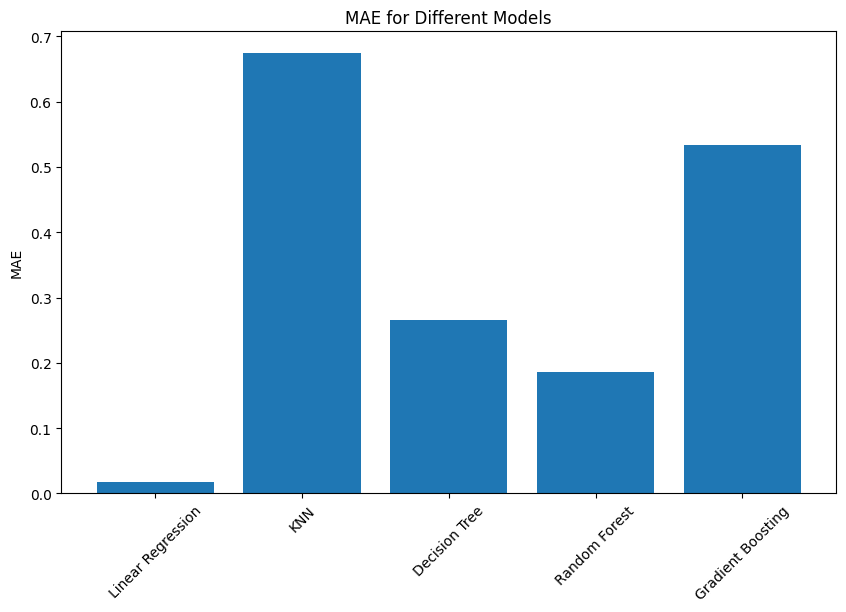

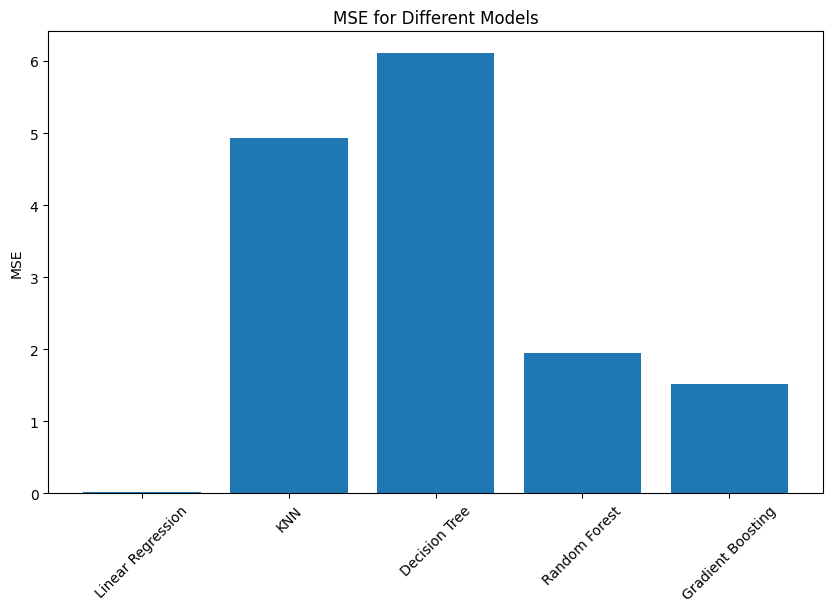

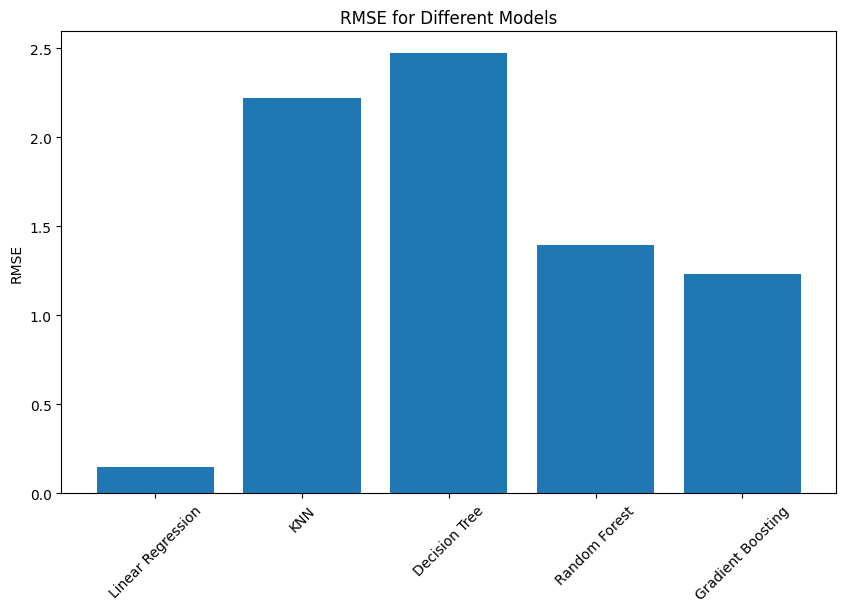

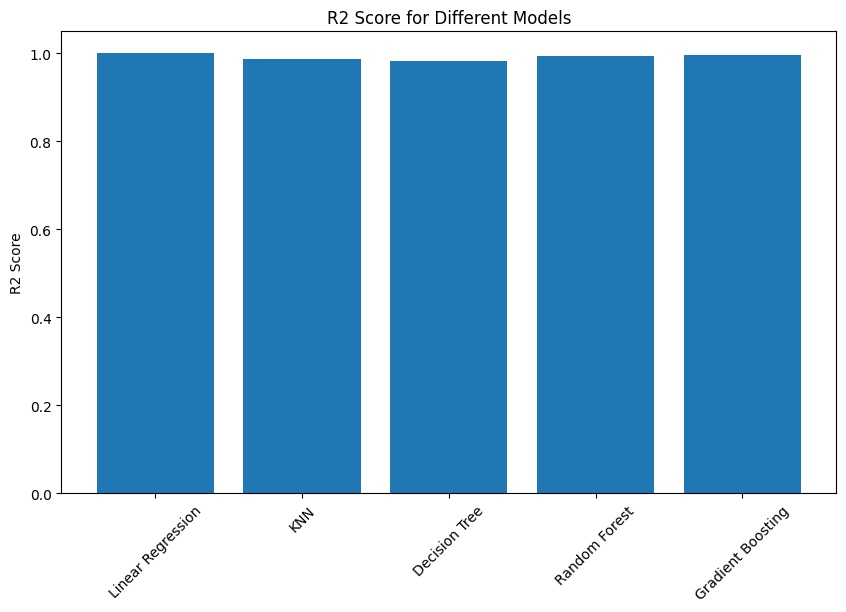

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = {
    "Model": ["Linear Regression", "KNN", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_lr, mae_knn, mae_dt, mae_rf, mae_gbr],
    "MSE": [mse_lr, mse_knn, mse_dt, mse_rf, mse_gbr],
    "RMSE": [rmse_lr, rmse_knn, rmse_dt, rmse_rf, rmse_gbr],
    "R2 Score": [r2_lr, r2_knn, r2_dt, r2_rf, r2_gbr]
}

results_df = pd.DataFrame(results)
print(results_df)


# Plot metrics
models = results_df['Model']
metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']

for metric in metrics:
    plt.figure(figsize=(10, 6))
    plt.bar(models, results_df[metric])
    plt.title(f'{metric} for Different Models')
    plt.xticks(rotation=45)
    plt.ylabel(metric)
    plt.show()


**Plotting the Best Regressor - LinearRegression  Actual vs Predicted**

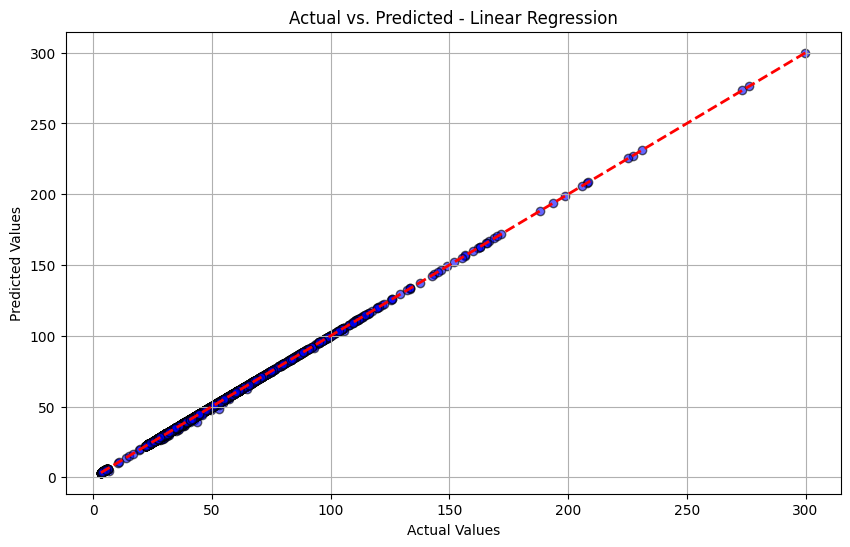

In [ ]:
import matplotlib.pyplot as plt

# Actual vs. Predicted Plot for Linear Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, edgecolors='k', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs. Predicted - Linear Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid()
plt.show()


**Plotting the Worst Model - KNN   Actual vs Prredicted**

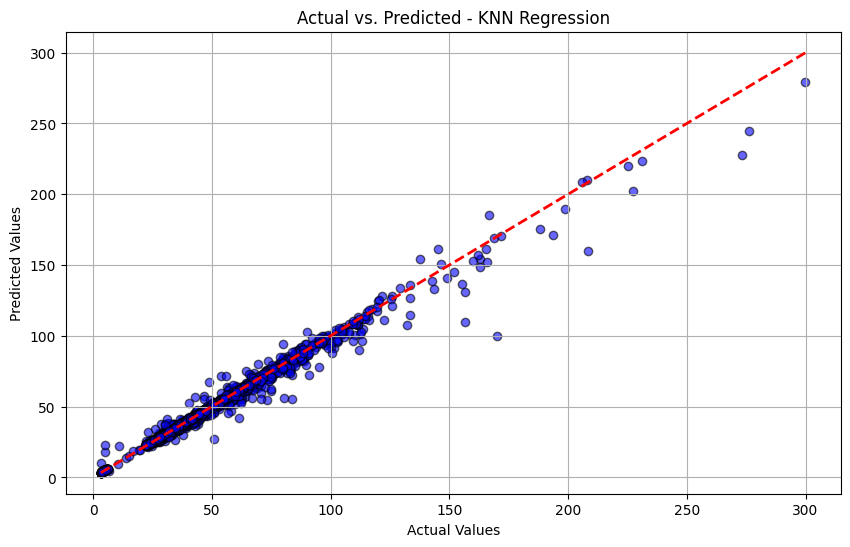

In [ ]:
# Actual vs. Predicted Plot for KNN Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.6, edgecolors='k', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs. Predicted - KNN Regression")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid()
plt.show()



**Summary**

```
Linear Regression performs exceptionally well on this dataset.

KNN performs relatively poorly, suggesting it's not a good fit for the taxi fare prediction problem in this case.
```

